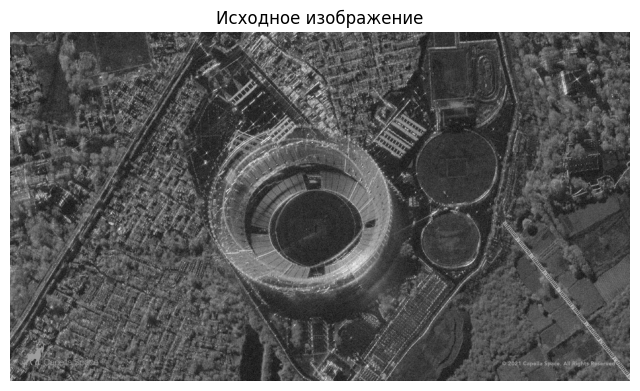

In [58]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Загрузка и подготовка изображения
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()



=== Добавление шума соль-перец ===


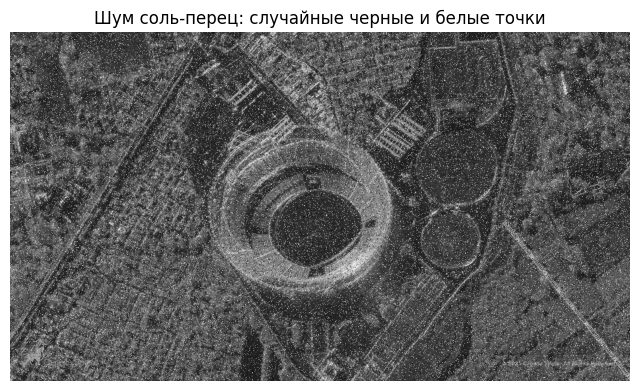

In [42]:
# 2. Шум соль-перец
print("\n=== Добавление шума соль-перец ===")
image_sp = image_gray.copy()
salt_pepper = np.random.random(image_gray.shape)
image_sp[salt_pepper < 0.05] = 0    # перец (5%)
image_sp[salt_pepper > 0.95] = 255  # соль (5%)

plt.figure(figsize=(8, 6))
plt.imshow(image_sp, cmap='gray')
plt.title('Шум соль-перец: случайные черные и белые точки')
plt.axis('off')
plt.show()



===  ФИЛЬТРАЦИЯ ГАУССОВА ШУМА ===

--- Медианный фильтр для гауссова шума ---


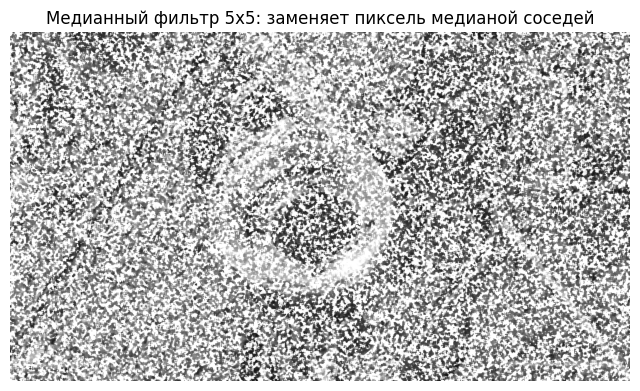

Медианный фильтр применен - хорошо сохраняет края


In [44]:
# ФИЛЬТРАЦИЯ ГАУССОВА ШУМА
print("\n===  ФИЛЬТРАЦИЯ ГАУССОВА ШУМА ===")
print("\n=== Медианный фильтр для гауссова шума ===")
median_gauss = cv2.medianBlur(image_noise_gauss, 5)
plt.figure(figsize=(8, 6))
plt.imshow(median_gauss, cmap='gray')
plt.title('Медианный фильтр 5x5: заменяет пиксель медианой соседей')
plt.axis('off')
plt.show()

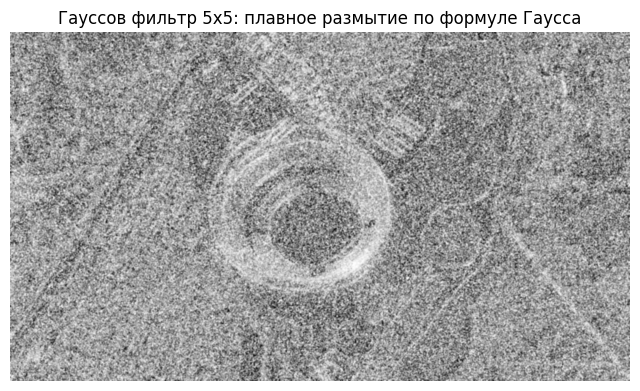

In [45]:
gaussian_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
plt.figure(figsize=(8, 6))
plt.imshow(gaussian_gauss, cmap='gray')
plt.title('Гауссов фильтр 5x5: плавное размытие по формуле Гаусса')
plt.axis('off')
plt.show()

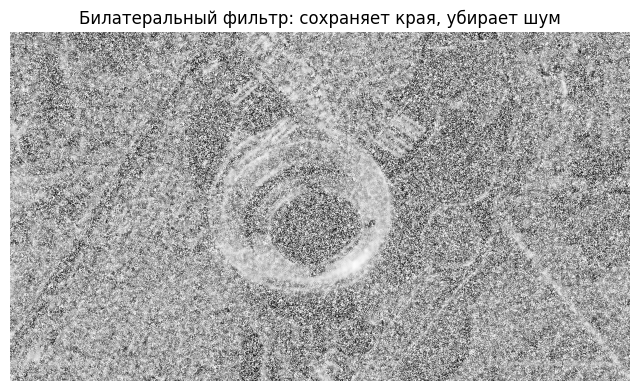

In [46]:
bilateral_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
plt.figure(figsize=(8, 6))
plt.imshow(bilateral_gauss, cmap='gray')
plt.title('Билатеральный фильтр: сохраняет края, убирает шум')
plt.axis('off')
plt.show()

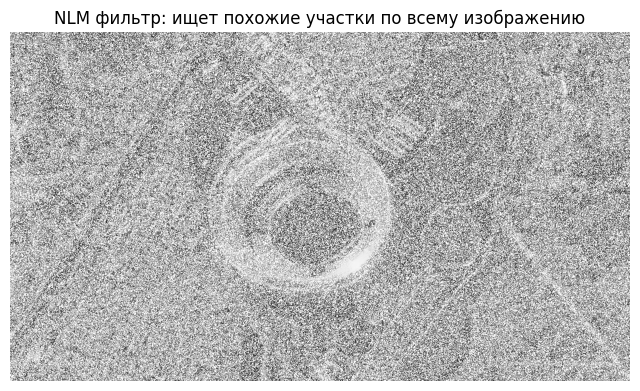

In [48]:
nlm_gauss = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
plt.figure(figsize=(8, 6))
plt.imshow(nlm_gauss, cmap='gray')
plt.title('NLM фильтр: ищет похожие участки по всему изображению')
plt.axis('off')
plt.show()


 ФИЛЬТРАЦИЯ ШУМА СОЛЬ-ПЕРЕЦ 

 Медианный фильтр для шума соль-перец 


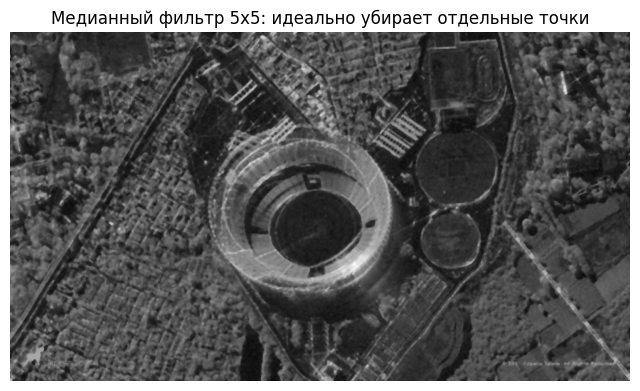

In [50]:
# ФИЛЬТРАЦИЯ ШУМА СОЛЬ-ПЕРЕЦ
print("\n ФИЛЬТРАЦИЯ ШУМА СОЛЬ-ПЕРЕЦ ")
print("\n Медианный фильтр для шума соль-перец ")
median_sp = cv2.medianBlur(image_sp, 5)
plt.figure(figsize=(8, 6))
plt.imshow(median_sp, cmap='gray')
plt.title('Медианный фильтр 5x5: идеально убирает отдельные точки')
plt.axis('off')
plt.show()

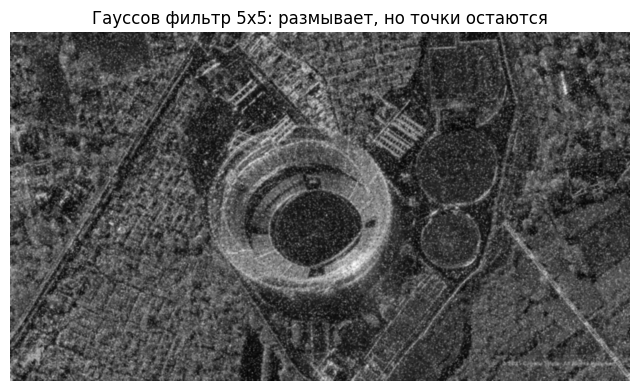

In [54]:
gaussian_sp = cv2.GaussianBlur(image_sp, (5, 5), 0)
plt.figure(figsize=(8, 6))
plt.imshow(gaussian_sp, cmap='gray')
plt.title('Гауссов фильтр 5x5: размывает, но точки остаются')
plt.axis('off')
plt.show()

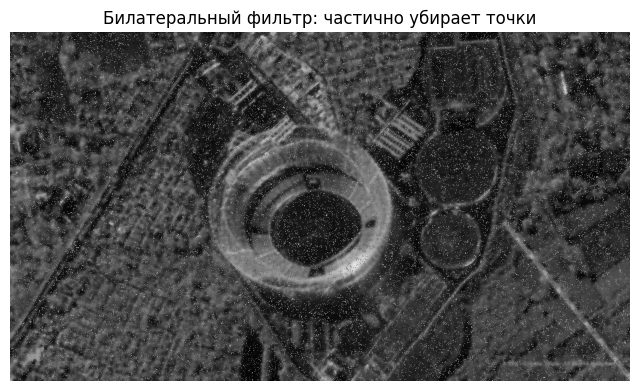

In [55]:
bilateral_sp = cv2.bilateralFilter(image_sp, 9, 75, 75)
plt.figure(figsize=(8, 6))
plt.imshow(bilateral_sp, cmap='gray')
plt.title('Билатеральный фильтр: частично убирает точки')
plt.axis('off')
plt.show()

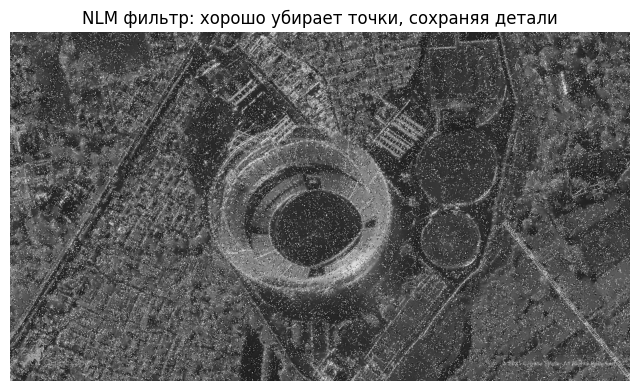

In [56]:
nlm_sp = cv2.fastNlMeansDenoising(image_sp, h=20)
plt.figure(figsize=(8, 6))
plt.imshow(nlm_sp, cmap='gray')
plt.title('NLM фильтр: хорошо убирает точки, сохраняя детали')
plt.axis('off')
plt.show()


  СРАВНЕНИЕ РЕЗУЛЬТАТОВ 


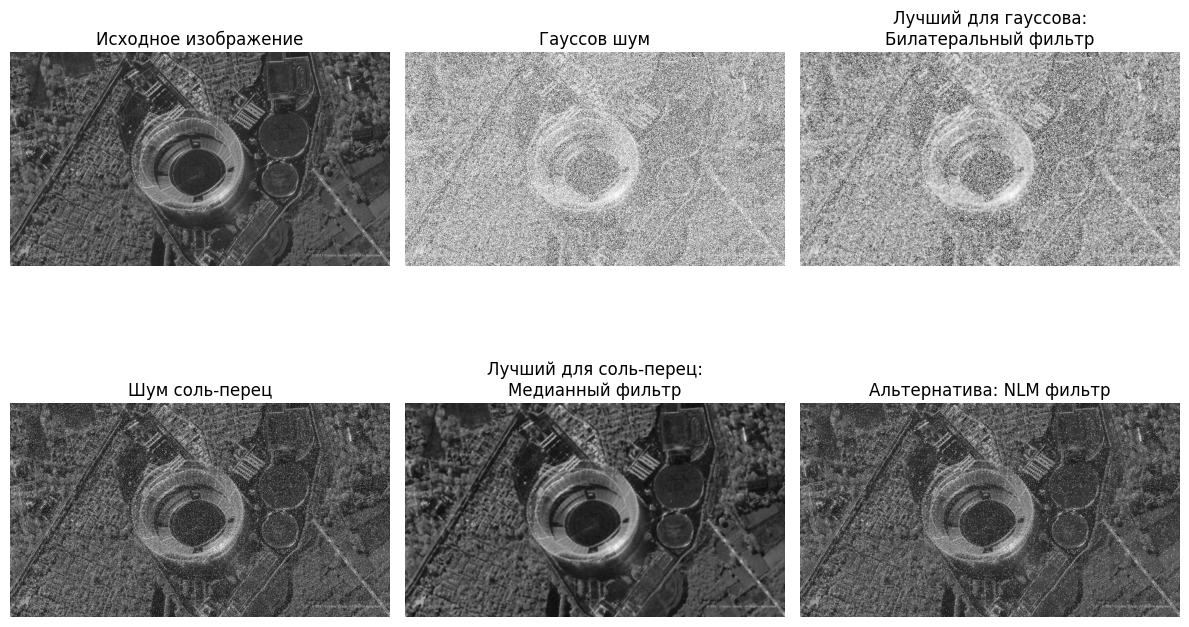

In [57]:
# ИТОГИ И СРАВНЕНИЕ
print("\n  СРАВНЕНИЕ РЕЗУЛЬТАТОВ ")

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(image_noise_gauss, cmap='gray')
plt.title('Гауссов шум')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(bilateral_gauss, cmap='gray')
plt.title('Лучший для гауссова:\nБилатеральный фильтр')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(image_sp, cmap='gray')
plt.title('Шум соль-перец')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(median_sp, cmap='gray')
plt.title('Лучший для соль-перец:\nМедианный фильтр')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(nlm_sp, cmap='gray')
plt.title('Альтернатива: NLM фильтр')
plt.axis('off')

plt.tight_layout()
plt.show()